In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from utils.constants import FIGURES_DIR, PROCESSED_DATA_DIR, DAY_OF_WEEK_MAP  # noqa: E402
from utils.load_data.processed import load_processed_original_data, resample_data  # noqa: E402

FIGSIZE = (8, 4)

LINEPLOT_FIGURES_DIR = FIGURES_DIR / "lineplots"
LINEPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BARPLOT_FIGURES_DIR = FIGURES_DIR / "barplots"
BARPLOT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [186]:
plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
    }
)

In [187]:
# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://seaborn.pydata.org/generated/seaborn.color_palette.html
palette = sns.color_palette("dark")
sns.set_palette(palette)
palette

[(0.0, 0.10980392156862745, 0.4980392156862745),
 (0.6941176470588235, 0.25098039215686274, 0.050980392156862744),
 (0.07058823529411765, 0.44313725490196076, 0.10980392156862745),
 (0.5490196078431373, 0.03137254901960784, 0.0),
 (0.34901960784313724, 0.11764705882352941, 0.44313725490196076),
 (0.34901960784313724, 0.1843137254901961, 0.050980392156862744),
 (0.6352941176470588, 0.20784313725490197, 0.5098039215686274),
 (0.23529411764705882, 0.23529411764705882, 0.23529411764705882),
 (0.7215686274509804, 0.5215686274509804, 0.0392156862745098),
 (0.0, 0.38823529411764707, 0.4549019607843137)]

In [206]:
original_df = load_processed_original_data(parse_dates=True)
# original_df["DIA_SEMANA_OCURRENCIA"] = original_df["DIA_SEMANA_OCURRENCIA"].map(DAY_OF_WEEK_MAP)

df = pd.read_csv(PROCESSED_DATA_DIR / "grouped.csv")
# df["DIA_SEMANA_OCURRENCIA"] = df["DIA_SEMANA_OCURRENCIA"].map(DAY_OF_WEEK_MAP)

sorted_original_df = original_df.sort_values(by="FECHA_OCURRENCIA").reset_index(
    drop=True
)

display(
    original_df.head(),
    df.head(),
    (
        sorted_original_df.iloc[0]["FECHA_OCURRENCIA"],
        sorted_original_df.iloc[-1]["FECHA_OCURRENCIA"],
    ),
)

,OBJECTID,FORMULARIO,CODIGO_ACCIDENTE,FECHA_OCURRENCIA,DIA_SEMANA_OCURRENCIA,GRAVEDAD,CLASE,LOCALIDAD,latitude,longitude
0,646545,A00410124,306211,2008-09-05 12:50:00,5,CON HERIDOS,ATROPELLO,TEUSAQUILLO,4.655402,-74.101700
1,563782,839933000,291565,2008-05-20 23:40:00,2,SOLO DANOS,CHOQUE,ENGATIVA,4.689417,-74.109351
2,4398952,A000038718,4398952,2014-12-04 17:30:00,4,SOLO DANOS,CHOQUE,ENGATIVA,4.689750,-74.109016
3,1612,726750500,30243,2007-06-29 19:30:00,5,CON HERIDOS,ATROPELLO,PUENTE ARANDA,4.615129,-74.108947
4,569692,840564600,297475,2008-07-21 07:30:00,1,SOLO DANOS,CHOQUE,TEUSAQUILLO,4.646696,-74.108792


,AÑO,DIA,MES,DIA_SEMANA_OCURRENCIA,LOCALIDAD,GRAVEDAD,CLASE,CANTIDAD
0,2007,1,1,1,BOSA,CON HERIDOS,ATROPELLO,1
1,2007,1,1,1,BOSA,SOLO DANOS,CHOQUE,2
2,2007,1,1,1,CANDELARIA,SOLO DANOS,CHOQUE,1
3,2007,1,1,1,CHAPINERO,CON HERIDOS,CHOQUE,1
4,2007,1,1,1,CHAPINERO,CON HERIDOS,VOLCAMIENTO,1


(Timestamp('2007-01-01 00:00:00'), Timestamp('2017-09-29 22:20:00'))

In [189]:
bound_datetime = (
    sorted_original_df.iloc[0]["FECHA_OCURRENCIA"],
    sorted_original_df.iloc[-1]["FECHA_OCURRENCIA"],
)

localities_col = original_df["LOCALIDAD"].unique().tolist()

## Datetime related

### Grouped by years

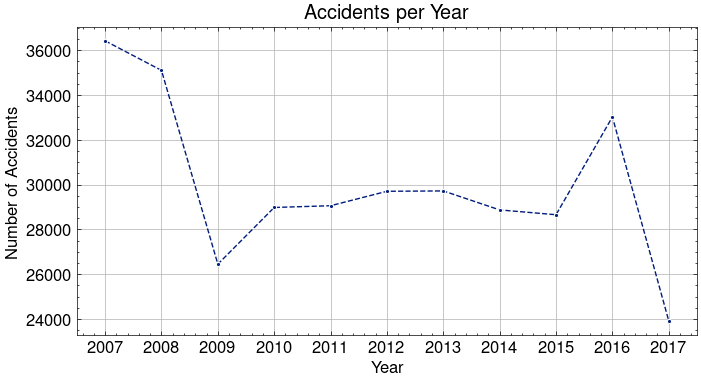

In [190]:
fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(data=df.groupby("AÑO").sum().reset_index(), x="AÑO", y="CANTIDAD", marker="o", linestyle="--", ax=ax)

ax.set(title="Accidents per Year", xlabel="Year", ylabel="Number of Accidents", xticks=df["AÑO"].unique())
ax.grid()

fig.savefig(LINEPLOT_FIGURES_DIR / "accidents_per_year.pdf")
plt.show()

### Grouped by day of week

In [203]:
df.groupby("DIA_SEMANA_OCURRENCIA").size().reset_index().rename(columns={0: "CANTIDAD"})

,DIA_SEMANA_OCURRENCIA,CANTIDAD
0,Domingo,17684
1,Jueves,20034
2,Lunes,19327
3,Martes,20091
4,Miercoles,20205
5,Sábado,20766
6,Viernes,20787


In [205]:
sub_df

,DIA_SEMANA_OCURRENCIA,AÑO,DIA,MES,LOCALIDAD,GRAVEDAD,CLASE,CANTIDAD
0,Domingo,35573953,276884,114170,ANTONIO NARIÑOANTONIO NARIÑOANTONIO NARIÑOBARR...,CON HERIDOSCON HERIDOSSOLO DANOSCON HERIDOSSOL...,CHOQUEOTROCHOQUECHOQUECHOQUEATROPELLOCAIDA DE ...,33054
1,Jueves,40305011,315232,129102,ANTONIO NARIÑOBARRIOS UNIDOSBARRIOS UNIDOSBARR...,SOLO DANOSCON HERIDOSCON HERIDOSSOLO DANOSCON ...,CHOQUEATROPELLOCHOQUECHOQUEOTROCHOQUECHOQUECHO...,48189
2,Lunes,38882155,306125,123385,BOSABOSACANDELARIACHAPINEROCHAPINEROCHAPINEROE...,CON HERIDOSSOLO DANOSSOLO DANOSCON HERIDOSCON ...,ATROPELLOCHOQUECHOQUECHOQUEVOLCAMIENTOCHOQUECH...,44583
3,Martes,40419902,314855,128798,BARRIOS UNIDOSBARRIOS UNIDOSBOSABOSABOSACANDEL...,CON HERIDOSSOLO DANOSCON HERIDOSCON MUERTOSSOL...,CHOQUECHOQUEATROPELLOCHOQUECHOQUECHOQUEATROPEL...,50063
4,Miercoles,40648737,318085,129992,ANTONIO NARIÑOBARRIOS UNIDOSBARRIOS UNIDOSBARR...,CON HERIDOSCON HERIDOSCON HERIDOSSOLO DANOSSOL...,CHOQUECHOQUEVOLCAMIENTOCHOQUECHOQUEATROPELLOCH...,49485
5,Sábado,41775125,326859,133620,ANTONIO NARIÑOANTONIO NARIÑOBARRIOS UNIDOSBOSA...,CON HERIDOSSOLO DANOSSOLO DANOSCON HERIDOSCON ...,CHOQUECHOQUECHOQUECHOQUEVOLCAMIENTOCHOQUEOTROC...,51450
6,Viernes,41819234,328605,133471,ANTONIO NARIÑOBARRIOS UNIDOSBOSACANDELARIACAND...,CON HERIDOSSOLO DANOSSOLO DANOSCON HERIDOSSOLO...,ATROPELLOCHOQUECHOQUEOTROCHOQUECHOQUECHOQUEATR...,53042


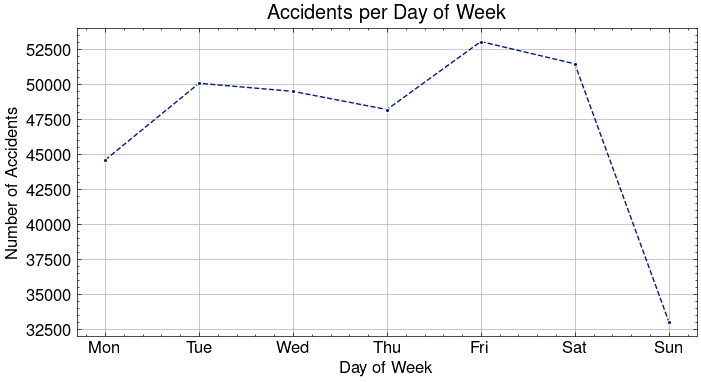

In [211]:
sub_df = df.groupby("DIA_SEMANA_OCURRENCIA").sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="DIA_SEMANA_OCURRENCIA",
    y="CANTIDAD",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Day of Week",
    ylabel="Number of Accidents",
)

ax.set_xticks(
    sorted(df["DIA_SEMANA_OCURRENCIA"].unique()),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
)

ax.grid()

fig.savefig(LINEPLOT_FIGURES_DIR / "accidents_per_day_of_week.pdf")
plt.show()

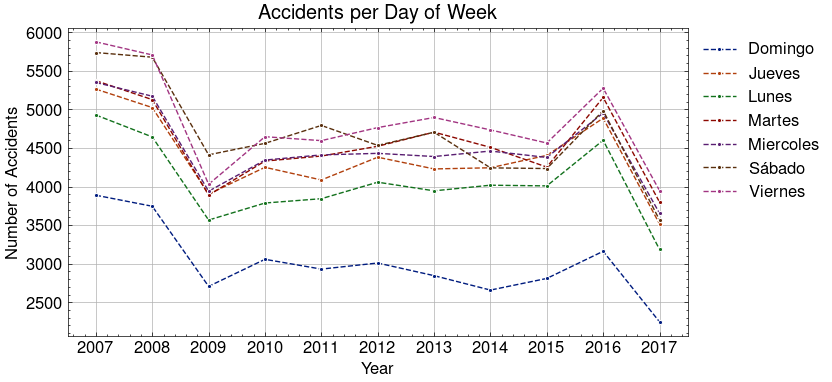

In [192]:
sub_df = df.groupby(["DIA_SEMANA_OCURRENCIA", "AÑO"]).sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="AÑO",
    y="CANTIDAD",
    hue="DIA_SEMANA_OCURRENCIA",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Year",
    ylabel="Number of Accidents",
    xticks=df["AÑO"].unique(),
)

ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

fig.savefig(LINEPLOT_FIGURES_DIR / "accidents_per_day_of_week_year.pdf")
plt.show()

### Grouped by month

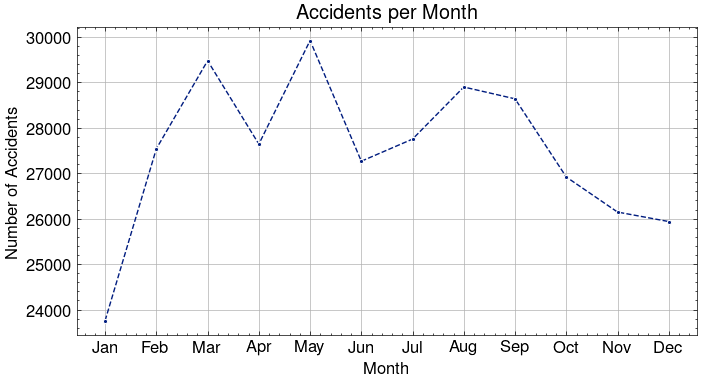

In [193]:
sub_df = df.groupby("MES").sum().reset_index()

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="MES",
    y="CANTIDAD",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Month",
    xlabel="Month",
    ylabel="Number of Accidents",
)

ax.set_xticks(
    sorted(df["MES"].unique()),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
)

ax.grid()

fig.savefig(LINEPLOT_FIGURES_DIR / "accidents_per_month.pdf")
plt.show()

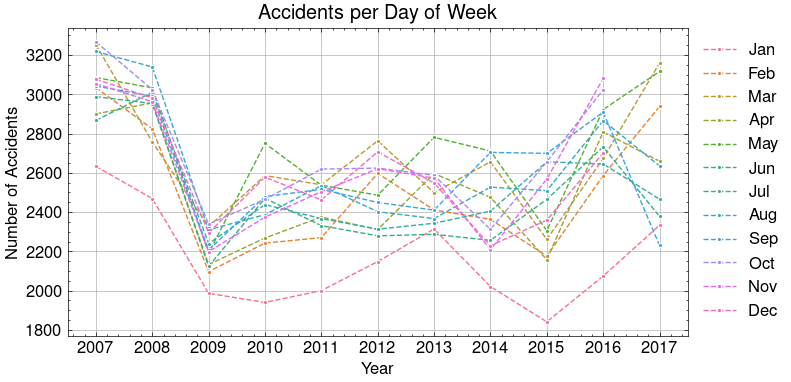

In [194]:
sub_df = df.groupby(["MES", "AÑO"]).sum().reset_index()
sub_df["MES"] = sub_df["MES"].replace({
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
})

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.lineplot(
    data=sub_df,
    x="AÑO",
    y="CANTIDAD",
    hue="MES",
    marker="o",
    linestyle="--",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week",
    xlabel="Year",
    ylabel="Number of Accidents",
    xticks=df["AÑO"].unique(),
)

ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

fig.savefig(LINEPLOT_FIGURES_DIR / "accidents_per_month_year.pdf")
plt.show()

### Group by all historic

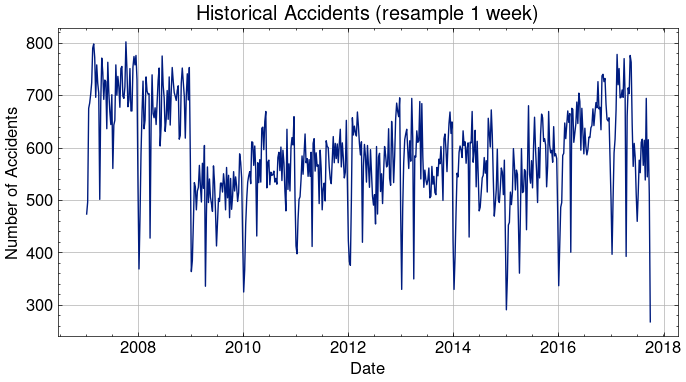

In [195]:
historical_df = original_df.set_index("FECHA_OCURRENCIA").resample("1W").size()
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.lineplot(data=historical_df, ax=ax)
ax.set(
    title="Historical Accidents (resample 1 week)",
    xlabel="Date",
    ylabel="Number of Accidents",
)

plt.grid()

fig.savefig(LINEPLOT_FIGURES_DIR / "historical_accidents.pdf")
plt.show()

## Locality related

Hacer una sola está bastante complicado, joder. Tocará hacer varias e ir comparando uno a uno

### Historical


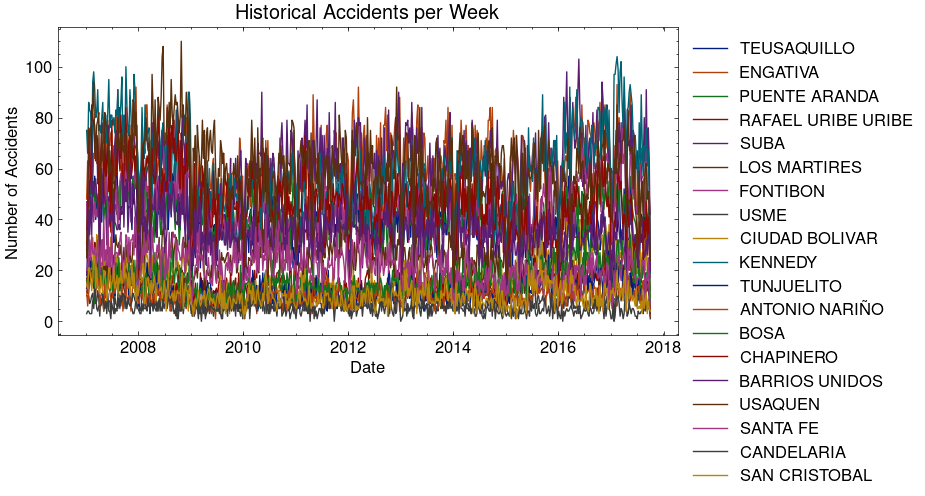

In [196]:
localities = {}
for locality in localities_col:
    localities[locality] = (
        original_df[original_df["LOCALIDAD"] == locality]
        .set_index("FECHA_OCURRENCIA")
        .resample("1W")
        .size()
    )

fig, ax = plt.subplots(figsize=FIGSIZE)

for locality, locality_df in localities.items():
    sns.lineplot(data=locality_df, ax=ax, label=locality)

ax.set(
    title="Historical Accidents per Week",
    xlabel="Date",
    ylabel="Number of Accidents",
)
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

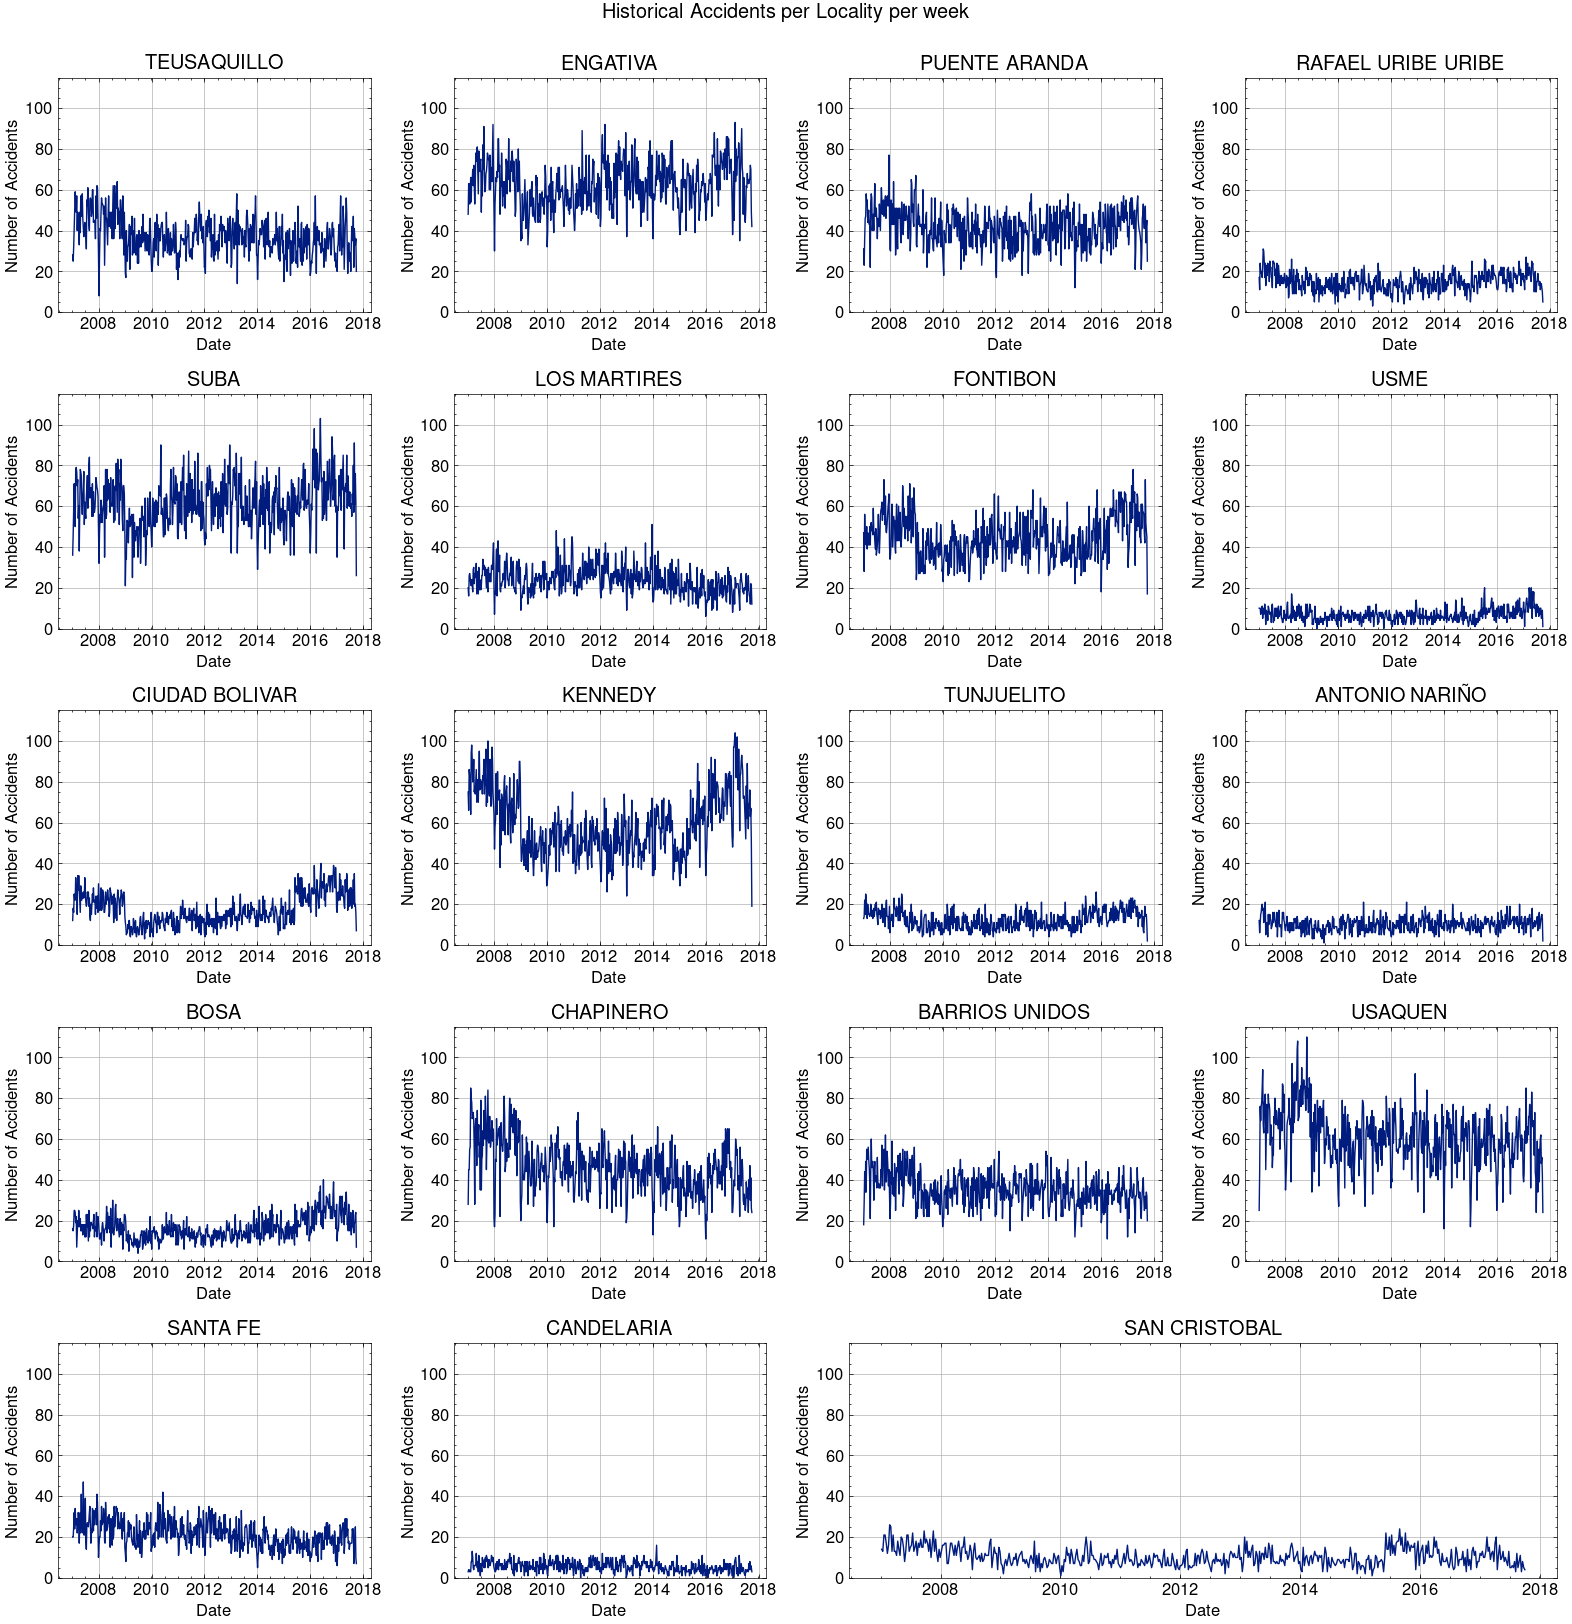

In [197]:
localities_col = original_df["LOCALIDAD"].unique().tolist()
localities = {}
for locality in localities_col:
    localities[locality] = (
        original_df[original_df["LOCALIDAD"] == locality]
        .set_index("FECHA_OCURRENCIA")
        .resample("1W")
        .size()
    )

locality_max = max(localities, key=lambda x: localities[x].max())
scale = localities[locality_max].max()

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(FIGSIZE[0] * 2, FIGSIZE[1] * 4))

# Para que no quede una cuadrícula vacía al final
# la concatenaré con la cuadrícula anterior
gs = axes[4, 2].get_gridspec()
for ax in axes[4, 2:]:
    ax.remove()

axbig = fig.add_subplot(gs[4, 2:])

for i, ((locality, locality_df), ax) in enumerate(
    zip(localities.items(), axes.flatten())
):
    if i >= 18:
        ax = axbig

    sns.lineplot(data=locality_df, ax=ax)
    ax.set(
        title=locality,
        xlabel="Date",
        ylabel="Number of Accidents",
        ylim=(0, scale + 5)
    )
    ax.grid()

fig.tight_layout()
fig.suptitle("Historical Accidents per Locality per week", y=1.02)
fig.savefig(LINEPLOT_FIGURES_DIR / "historical_accidents_per_locality.pdf")
plt.show()

### Day of week

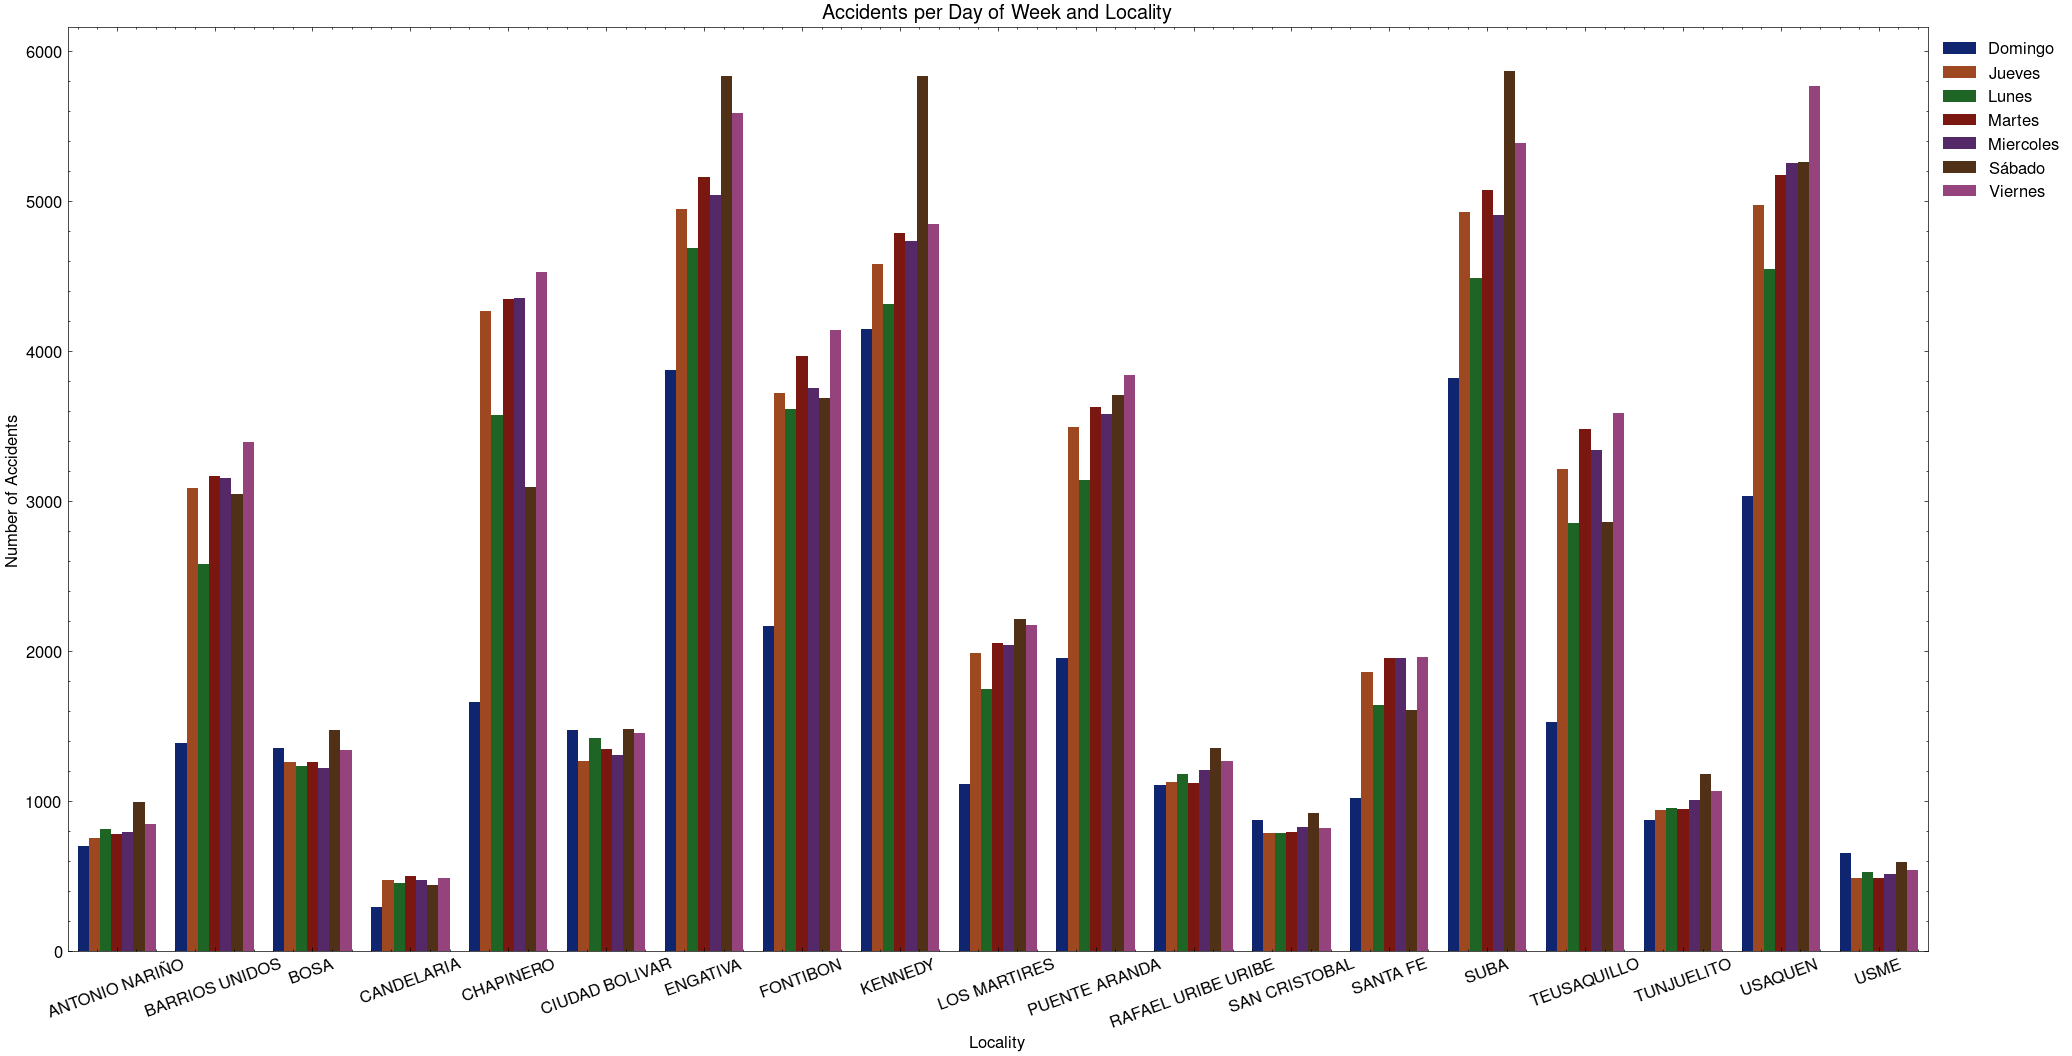

In [198]:
sub_df = df.groupby(["DIA_SEMANA_OCURRENCIA", "LOCALIDAD"]).sum().reset_index()

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 3, FIGSIZE[1] * 3))

sns.barplot(
    data=sub_df,
    x="LOCALIDAD",
    y="CANTIDAD",
    hue="DIA_SEMANA_OCURRENCIA",
    ax=ax,
)

ax.set(
    title="Accidents per Day of Week and Locality",
    xlabel="Locality",
    ylabel="Number of Accidents",
)

plt.xticks(rotation=20, ha="center")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")
fig.savefig(BARPLOT_FIGURES_DIR / "accidents_per_day_of_week_locality.pdf")
plt.show()